In [1]:
import os
import pandas as pd
import torch
import numpy
import pandas
import matplotlib
import json
import re
from tqdm import tqdm

os.chdir('D:/vscode/aiffel/2026/09/16')

# 현재 이동한 위치 확인
print("현재 파이썬 작업 경로:", os.getcwd())
print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

현재 파이썬 작업 경로: D:\vscode\aiffel\2026\09\16
2.5.1+cu121
2.5.2
3.0.5
3.11.1
2.0.9
2.2.1
device: cuda


In [2]:
import os
import random
import numpy as np
import torch
from tokenizers import BertWordPieceTokenizer
import json


# 1. 시드(Seed) 고정 함수
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set to {seed}")


set_seed(42)

# 2. 경로 및 설정값
DATA_DIR = "./data"  # kowiki.txt 가 들어있는 폴더 경로
MODEL_DIR = "./model"  # 학습된 토크나이저가 저장될 폴더 경로

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

corpus_file = os.path.join(DATA_DIR, "kowiki.txt")
vocab_size = 8000  # 원하시는 보캡 크기 (8000)

# 3. BertWordPieceTokenizer 객체 생성 및 학습
vocab_file = os.path.join(MODEL_DIR, "vocab.txt")

if not os.path.exists(vocab_file):
    print("BertWordPieceTokenizer 학습 시작...")

    tokenizer = BertWordPieceTokenizer(
        clean_text=True,
        handle_chinese_chars=True,
        strip_accents=False,  # 한국어 음소/음절 보존을 위해 False 추천
        lowercase=False,
    )

    # 토크나이저 학습
    # special_tokens 순서대로 ID 할당: [PAD]=0, [UNK]=1, [CLS]=2, [SEP]=3, [MASK]=4
    tokenizer.train(
        files=[corpus_file],
        vocab_size=vocab_size,
        min_frequency=5,  # 최소 5회 이상 등장한 단어만 Vocab에 포함
        special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
    )

    # 학습된 vocab.txt 파일 저장
    tokenizer.save_model(MODEL_DIR)
    print("토크나이저 학습 완료!")
else:
    print("이미 학습된 vocab.txt 파일이 존재합니다.")
    tokenizer = BertWordPieceTokenizer(vocab_file, lowercase=False)


MAX_SAMPLES = 100000
corpus = []

with open(corpus_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            corpus.append(line)
        if len(corpus) >= MAX_SAMPLES:
            break

print(f"📖 텍스트 파일 로드 완료: 총 {len(corpus):,}개 문장")

# 2. JSON Pretrain 데이터셋 생성 함수 (루브릭 충족)
JSON_PATH = os.path.join(DATA_DIR, "bert_pretrain.json")


def build_and_save_bert_json(
    corpus, tokenizer, output_path, max_len=64, mask_prob=0.15
):
    dataset_list = []

    # BertWordPieceTokenizer의 특수 토큰 ID 추출
    pad_idx = tokenizer.token_to_id("[PAD]")
    cls_idx = tokenizer.token_to_id("[CLS]")
    sep_idx = tokenizer.token_to_id("[SEP]")
    mask_idx = tokenizer.token_to_id("[MASK]")

    print("🚀 Pretrain JSON 데이터셋 생성 시작...")

    for idx in tqdm(range(len(corpus) - 1)):
        # NSP 문장 쌍 생성 (50% 확률)
        sent_a = corpus[idx]
        if random.random() < 0.5:
            sent_b = corpus[idx + 1]
            is_next = 1
        else:
            sent_b = random.choice(corpus)
            is_next = 0

        # 토큰화
        tokens_a = tokenizer.encode(sent_a).ids
        tokens_b = tokenizer.encode(sent_b).ids

        # [CLS] + A + [SEP] + B + [SEP]
        input_ids = [cls_idx] + tokens_a + [sep_idx] + tokens_b + [sep_idx]
        segment_label = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

        # Truncation
        if len(input_ids) > max_len:
            input_ids = input_ids[:max_len]
            segment_label = segment_label[:max_len]

        # MLM 마스킹 처리 (80% [MASK], 10% Random, 10% Same)
        mlm_target = [-100] * len(input_ids)
        for i in range(len(input_ids)):
            if input_ids[i] in [cls_idx, sep_idx, pad_idx]:
                continue

            if random.random() < mask_prob:
                mlm_target[i] = input_ids[i]
                prob = random.random()
                if prob < 0.8:
                    input_ids[i] = mask_idx
                elif prob < 0.9:
                    input_ids[i] = random.randint(5, vocab_size - 1)

        # Padding
        pad_len = max_len - len(input_ids)
        if pad_len > 0:
            input_ids += [pad_idx] * pad_len
            segment_label += [0] * pad_len
            mlm_target += [-100] * pad_len

        dataset_list.append(
            {
                "input_ids": input_ids,
                "segment_label": segment_label,
                "mlm_target": mlm_target,
                "is_next": is_next,
            }
        )

    # JSON 저장
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(dataset_list, f, ensure_ascii=False)

    print(f"💾 JSON 데이터셋 저장 완료: {output_path}")


# 실행 (기존 json이 없을 때만 생성)
if not os.path.exists(JSON_PATH):
    build_and_save_bert_json(
        corpus, tokenizer, JSON_PATH, max_len=64, mask_prob=0.15
    )
else:
    print(f"이미 {JSON_PATH} 파일이 존재합니다.")
    

print("모델 저장 폴더 목록:", os.listdir(MODEL_DIR))

Seed set to 42
이미 학습된 vocab.txt 파일이 존재합니다.
📖 텍스트 파일 로드 완료: 총 100,000개 문장
이미 ./data\bert_pretrain.json 파일이 존재합니다.
모델 저장 폴더 목록: ['vocab.txt']


In [3]:
import json
import os
import random
import torch
from torch.utils.data import Dataset
from tqdm import tqdm


class BERTPretrainDataset(Dataset):

    def __init__(
        self,
        corpus_path=None,
        tokenizer=None,
        json_path="./data/bert_pretrain.json",
        seq_len=64,
        mask_prob=0.15,
        max_lines=100000,
    ):
        self.data = []

        # 1. 이미 저장된 JSON 데이터셋이 있는 경우 -> 초고속 로드
        if os.path.exists(json_path):
            print(f"📖 기존 Pretrain JSON 데이터셋 발견! 빠르게 로딩합니다: {json_path}")
            with open(json_path, "r", encoding="utf-8") as f:
                self.data = json.load(f)
            print(f"✅ 로드 완료: 총 {len(self.data):,}개 샘플")

        # 2. JSON 데이터셋이 없는 경우 -> 텍스트 전처리, WWM 마스킹 수행 후 JSON 자동 저장
        else:
            print(
                f"⚙️ {json_path} 파일이 없습니다. 텍스트 가공 및 JSON 생성을 시작합니다..."
            )
            assert (
                corpus_path and tokenizer
            ), "JSON 파일이 없을 때는 corpus_path와 tokenizer 인자가 필수입니다."

            self._build_and_save_dataset(
                corpus_path, tokenizer, json_path, seq_len, mask_prob, max_lines
            )

    def _build_and_save_dataset(
        self, corpus_path, tokenizer, json_path, seq_len, mask_prob, max_lines
    ):
        """기존 WWM 및 NSP 로직을 수행하여 JSON으로 생성 및 저장하는 내부 메서드"""
        # 1) kowiki.txt 읽기
        lines = []
        with open(corpus_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    lines.append(line)
                if len(lines) >= max_lines:
                    break

        corpus_lines = len(lines)
        print(f"📖 텍스트 읽기 완료: 총 {corpus_lines:,}개 문장")

        mask_id = tokenizer.token_to_id("[MASK]")
        pad_id = tokenizer.token_to_id("[PAD]")
        vocab_size = tokenizer.get_vocab_size()

        print("🚀 [WWM 적용] Pretrain 데이터 전처리 진행 중...")
        for idx in tqdm(range(corpus_lines)):
            # --- [A] NSP 문장 페어 생성 ---
            t1 = lines[idx]
            if random.random() > 0.5:
                t2 = (
                    lines[idx + 1]
                    if idx + 1 < corpus_lines
                    else lines[random.randint(0, corpus_lines - 1)]
                )
                is_next = 1
            else:
                t2 = lines[random.randint(0, corpus_lines - 1)]
                is_next = 0

            # --- [B] 토큰화 ---
            t1_tokens = tokenizer.encode(t1).tokens[1:-1]
            t2_tokens = tokenizer.encode(t2).tokens[1:-1]

            # Truncation
            max_num_tokens = seq_len - 3
            while len(t1_tokens) + len(t2_tokens) > max_num_tokens:
                if len(t1_tokens) > len(t2_tokens):
                    t1_tokens.pop()
                else:
                    t2_tokens.pop()

            tokens = ["[CLS]"] + t1_tokens + ["[SEP]"] + t2_tokens + ["[SEP]"]
            segment_label = (
                [0] * (len(t1_tokens) + 2) + [1] * (len(t2_tokens) + 1)
            )

            # --- [C] 어절 단위(WWM) 마스킹 (80:10:10) ---
            cand_idx = []
            for i, token in enumerate(tokens):
                if token in ["[CLS]", "[SEP]"]:
                    continue
                if len(cand_idx) > 0 and token.startswith("##"):
                    cand_idx[-1].append(i)
                else:
                    cand_idx.append([i])

            num_to_mask = max(1, int(round(len(cand_idx) * mask_prob)))
            random.shuffle(cand_idx)

            input_ids = [tokenizer.token_to_id(t) for t in tokens]
            mlm_target = [-100] * len(tokens)

            for index_set in cand_idx[:num_to_mask]:
                for i in index_set:
                    original_id = input_ids[i]
                    prob = random.random()

                    if prob < 0.8:
                        input_ids[i] = mask_id
                    elif prob < 0.9:
                        input_ids[i] = random.randint(5, vocab_size - 1)

                    mlm_target[i] = original_id

            # --- [D] Padding ---
            padding_len = seq_len - len(input_ids)
            input_ids.extend([pad_id] * padding_len)
            segment_label.extend([pad_id] * padding_len)
            mlm_target.extend([-100] * padding_len)

            self.data.append(
                {
                    "input_ids": input_ids,
                    "segment_label": segment_label,
                    "mlm_target": mlm_target,
                    "nsp_target": is_next,
                }
            )

        # JSON 자동 저장
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(self.data, f, ensure_ascii=False)
        print(f"💾 JSON 파일 자동 생성 및 저장 완료: {json_path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
    
        # 'nsp_target' 키가 없으면 기존 'is_next' 키에서 가져오도록 처리
        nsp_val = item.get("nsp_target", item.get("is_next"))
    
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "segment_label": torch.tensor(
                item["segment_label"], dtype=torch.long
            ),
            "mlm_target": torch.tensor(item["mlm_target"], dtype=torch.long),
            "nsp_target": torch.tensor(nsp_val, dtype=torch.long),
        }
        
    

    def random_sent(self, index):
        """NSP용 문장 페어 생성 (50% IsNext, 50% NotNext)"""
        t1 = self.lines[index]
        if random.random() > 0.5:
            t2 = (
                self.lines[index + 1]
                if index + 1 < self.corpus_lines
                else self.lines[random.randint(0, self.corpus_lines - 1)]
            )
            return t1, t2, 1
        else:
            t2 = self.lines[random.randint(0, self.corpus_lines - 1)]
            return t1, t2, 0

    def random_wwm_mask(self, tokens):
        """WordPiece '##' 기반 어절 단위(Whole Word Masking) 80:10:10 처리"""
        cand_idx = []

        # 1. 어절 단위로 인덱스 그룹화
        for i, token in enumerate(tokens):
            if token in ["[CLS]", "[SEP]"]:
                continue

            # WordPiece에서는 '##'로 시작하면 앞 단어에 붙는 서브워드입니다.
            if len(cand_idx) > 0 and token.startswith("##"):
                cand_idx[-1].append(i)
            else:
                cand_idx.append([i])

        # 전체 어절 개수의 15%를 마스킹 대상으로 결정
        num_to_mask = max(1, int(round(len(cand_idx) * self.mask_prob)))
        random.shuffle(cand_idx)

        mask_id = self.tokenizer.token_to_id("[MASK]")
        vocab_size = self.tokenizer.get_vocab_size()

        input_ids = [self.tokenizer.token_to_id(t) for t in tokens]
        masked_label = [0] * len(tokens)  # 기본값은 Loss 계산 제외(0)

        # 2. 선택된 어절 그룹 통째로 마스킹 적용
        for index_set in cand_idx[:num_to_mask]:
            for i in index_set:
                original_id = input_ids[i]
                prob = random.random()

                # 80% [MASK]
                if prob < 0.8:
                    input_ids[i] = mask_id
                # 10% Random Token
                elif prob < 0.9:
                    input_ids[i] = random.randint(5, vocab_size - 1)
                # 10% Original Token 유지
                else:
                    input_ids[i] = original_id

                # 정답 라벨 기록
                masked_label[i] = original_id

        return input_ids, masked_label

In [4]:
import torch
import torch.nn as nn


class PositionalEmbedding(nn.Module):

    def __init__(self, max_len=512, d_model=128):
        super().__init__()
        self.pos_emb = nn.Embedding(max_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        seq_len = x.size(1)
        positions = torch.arange(seq_len, dtype=torch.long, device=x.device)

        # (seq_len, d_model) -> (1, seq_len, d_model) 로 차원 확장
        # 이렇게 해두어야 (batch_size, seq_len, d_model)인 Token 임베딩과 더해질 때 자동 Broadcasting 됩니다.
        return self.pos_emb(positions).unsqueeze(0)


class BERTEmbedding(nn.Module):

    def __init__(self, vocab_size, d_model, max_len=512, dropout=0.1):
        super().__init__()
        # 1. Token Embedding
        self.token = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # 2. Segment (Token Type) Embedding (0: 문장A, 1: 문장B, PAD: 0)
        self.segment = nn.Embedding(3, d_model, padding_idx=0)

        # 3. Positional Embedding (max_len 동기화)
        self.position = PositionalEmbedding(max_len=max_len, d_model=d_model)

        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, sequence, segment_label):
        # sequence: input_ids (batch_size, seq_len)
        # segment_label: segment_label (batch_size, seq_len)

        # (batch, seq_len, d_model) 차원으로 3개 임베딩이 깔끔하게 합쳐집니다.
        x = (
            self.token(sequence)
            + self.position(sequence)
            + self.segment(segment_label)
        )
        return self.dropout(self.norm(x))

In [5]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert (
            d_model % num_heads == 0
        ), "d_model은 num_heads로 나누어 떨어져야 합니다."

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):
        # x: [batch_size, seq_len, d_model]
        batch_size, seq_len, _ = x.size()

        # 1. Q, K, V 분할 [batch_size, num_heads, seq_len, d_k]
        q = (
            self.W_q(x)
            .view(batch_size, seq_len, self.num_heads, self.d_k)
            .transpose(1, 2)
        )
        k = (
            self.W_k(x)
            .view(batch_size, seq_len, self.num_heads, self.d_k)
            .transpose(1, 2)
        )
        v = (
            self.W_v(x)
            .view(batch_size, seq_len, self.num_heads, self.d_k)
            .transpose(1, 2)
        )

        # 2. Scaled Dot-Product Attention 계산
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 3. BERT는 Causal Mask 없이 Padding Mask만 적용
        if mask is not None:
            if mask.dim() == 2:
                # [batch_size, seq_len] -> [batch_size, 1, 1, seq_len]
                mask = mask.unsqueeze(1).unsqueeze(2)

            # mask가 0인 위치([PAD] 토큰)에 매우 작은 음수값 부여
            scores = scores.masked_fill(mask == 0, -1e9)

        # 4. Softmax 및 Dropout
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 5. Context Vector 계산 및 병합
        context = torch.matmul(attn_weights, v)
        context = (
            context.transpose(1, 2)
            .contiguous()
            .view(batch_size, seq_len, self.d_model)
        )

        output = self.out_proj(context)
        return output, attn_weights

In [6]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

In [7]:
import torch
import torch.nn as nn


class EncoderBlock(nn.Module):

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_model=d_model, num_heads=num_heads, dropout=dropout
        )
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = PositionwiseFeedForward(
            d_model=d_model, d_ff=d_ff, dropout=dropout
        )
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 1. Multi-Head Attention + Residual Connection & LayerNorm
        attn_out, attn_weights = self.attention(x, mask=mask)
        x = self.norm1(x + self.dropout(attn_out))

        # 2. Position-wise Feed Forward + Residual Connection & LayerNorm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))

        return x, attn_weights

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. Masked Language Model (MLM) Head
# ==========================================
class MaskedLanguageModel(nn.Module):
    """
    [MASK] 토큰 위치의 원본 단어를 예측하는 헤드
    - Linear -> GELU -> LayerNorm -> Linear (vocab_size로 사상)
    """
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.fc = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, vocab_size, bias=True)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        x = self.fc(x)
        x = F.gelu(x)
        x = self.norm(x)
        # logits shape: [batch_size, seq_len, vocab_size]
        logits = self.decoder(x)
        return logits


# ==========================================
# 2. Next Sentence Prediction (NSP) Head
# ==========================================
class NextSentencePrediction(nn.Module):
    """
    두 문장이 이어지는 문장인지 이진 분류하는 헤드
    - 맨 첫 번째 [CLS] 토큰의 벡터만 추출하여 선형 변환
    """
    def __init__(self, d_model):
        super().__init__()
        self.fc = nn.Linear(d_model, 2)  # [IsNext(0), NotNext(1)] 2개 클래스

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        # [CLS] 토큰 위치인 0번째 인덱스만 추출: [batch_size, d_model]
        cls_out = x[:, 0, :]
        # logits shape: [batch_size, 2]
        logits = self.fc(cls_out)
        return logits


# ==========================================
# 3. 최종 BERT 메인 모델 클래스
# ==========================================
class BERT(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_layers=2, num_heads=4, d_ff=512, max_len=64, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # 1. BERT 임베딩 레이어 (Token + Position + Segment)
        self.embedding = BERTEmbedding(vocab_size=vocab_size, d_model=d_model, max_len=max_len, dropout=dropout)
        
        # 2. Transformer Encoder Layer N개 쌓기
        self.encoder_layers = nn.ModuleList([
            EncoderBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])
        
        # 3. Task-specific Output Heads
        self.mlm_head = MaskedLanguageModel(d_model=d_model, vocab_size=vocab_size)
        self.nsp_head = NextSentencePrediction(d_model=d_model)

    def forward(self, x, segment_label, mask=None):
        """
        - x: [batch_size, seq_len] (정수 토큰 ID)
        - segment_label: [batch_size, seq_len] (0 또는 1의 세그먼트 ID)
        - mask: [batch_size, 1, 1, seq_len] 또는 [batch_size, 1, seq_len, seq_len] (Padding Mask)
        """
        # 1. 임베딩 계산 -> [batch_size, seq_len, d_model]
        x = self.embedding(x, segment_label)
        
        # 2. 인코더 블록들 순차 통과
        all_attn_weights = []
        for layer in self.encoder_layers:
            x, attn_weights = layer(x, mask=mask)
            all_attn_weights.append(attn_weights)
            
        # 3. MLM 및 NSP 헤드 계산
        mlm_logits = self.mlm_head(x)      # [batch_size, seq_len, vocab_size]
        nsp_logits = self.nsp_head(x)      # [batch_size, 2]
        
        return mlm_logits, nsp_logits, all_attn_weights

In [9]:
import torch

vocab_file = os.path.join(MODEL_DIR, "vocab.txt")
tokenizer = BertWordPieceTokenizer(vocab_file)

VOCAB_SIZE = tokenizer.get_vocab_size()
D_MODEL = 128
NUM_LAYERS = 3
NUM_HEADS = 4
D_FF = 512
MAX_LEN = 64
BATCH_SIZE = 32

# 2. 모델 인스턴스화
model = BERT(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    max_len=MAX_LEN,
)

# 3. Dummy 입력 데이터 생성
# (1) 입력 토큰 ID: [Batch=2, Seq_Len=64]
dummy_x = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, MAX_LEN))

# (2) 세그먼트 ID: 첫 32개는 문장 A(0), 나머지 32개는 문장 B(1)
dummy_segment = torch.cat(
    [
        torch.zeros((BATCH_SIZE, MAX_LEN // 2), dtype=torch.long),
        torch.ones((BATCH_SIZE, MAX_LEN // 2), dtype=torch.long),
    ],
    dim=1,
)

# (3) 패딩 마스크: [Batch, 1, 1, Seq_Len] (여기선 모두 1로 설정)
dummy_mask = (dummy_x != 0).unsqueeze(1).unsqueeze(2)

# 4. Forward Path 테스트
mlm_logits, nsp_logits, attn_weights = model(
    dummy_x, dummy_segment, mask=dummy_mask
)

# 5. 파라미터 개수 계산
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# 6. 결과 출력
print("=== 🧪 BERT Forward Test 결과 ===")
print(
    f"1. MLM Output Shape  : {mlm_logits.shape}  (기대: [{BATCH_SIZE}, {MAX_LEN}, {VOCAB_SIZE}])"
)
print(
    f"2. NSP Output Shape  : {nsp_logits.shape}       (기대: [{BATCH_SIZE}, 2])"
)
print(f"3. Layer별 Attn 개수 : {len(attn_weights)}개")
print(
    f"4. Attention Shape   : {attn_weights[0].shape} (기대: [{BATCH_SIZE}, {NUM_HEADS}, {MAX_LEN}, {MAX_LEN}])"
)
print("-" * 40)
print(
    f"📊 총 학습 가능 파라미터 수: {total_params:,}개 ({total_params/1e6:.2f}M)"
)

=== 🧪 BERT Forward Test 결과 ===
1. MLM Output Shape  : torch.Size([32, 64, 8000])  (기대: [32, 64, 8000])
2. NSP Output Shape  : torch.Size([32, 2])       (기대: [32, 2])
3. Layer별 Attn 개수 : 3개
4. Attention Shape   : torch.Size([32, 4, 64, 64]) (기대: [32, 4, 64, 64])
----------------------------------------
📊 총 학습 가능 파라미터 수: 2,676,674개 (2.68M)


In [11]:

import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# ⚡ 1. GPU(CUDA) 사용 여부 확인 및 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 사용 중인 디바이스: {device}")

# 2. JSON 데이터셋 로드 및 DataLoader 구축
JSON_FILE_PATH = "./data/bert_pretrain.json"

# 아까 정의한 BERTJsonDataset 클래스 사용
dataset = BERTPretrainDataset(
    corpus_path=os.path.join(DATA_DIR, "kowiki.txt"),
    tokenizer=tokenizer,
    json_path=JSON_FILE_PATH,
    seq_len=64,
)

BATCH_SIZE = 64
train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True if device.type == "cuda" else False,
)

# 3. 모델 및 체크포인트 설정
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# 모델을 GPU로 이동
model = model.to(device)

criterion_mlm = nn.CrossEntropyLoss(ignore_index=-100)
criterion_nsp = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# 4. 10 Epochs 학습 루프
model.train()
EPOCHS = 10

print(f"\n🚀 [Pretrain JSON] BERT 사전 학습 시작...")
print(f"📊 총 배치(Iteration) 수: 에포크당 {len(train_loader):,} steps\n")

for epoch in range(1, EPOCHS + 1):
    total_epoch_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_loss = 0.0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch:02d}/{EPOCHS}]",
        leave=True,
        dynamic_ncols=True
    )

    for step, batch in enumerate(pbar, 1):
        optimizer.zero_grad()

        # GPU로 Tensor 이동
        input_ids = batch["input_ids"].to(device)
        segment_label = batch["segment_label"].to(device)
        mlm_target = batch["mlm_target"].to(device)
        nsp_target = batch["nsp_target"].to(device)

        mask = (input_ids != 0).unsqueeze(1).unsqueeze(2).to(device)

        # Forward
        mlm_logits, nsp_logits, _ = model(input_ids, segment_label, mask=mask)

        # Loss 계산
        loss_mlm = criterion_mlm(
            mlm_logits.view(-1, VOCAB_SIZE), mlm_target.view(-1)
        )
        loss_nsp = criterion_nsp(nsp_logits, nsp_target)
        loss = loss_mlm + loss_nsp

        # Backward & Optimization
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_loss += loss_nsp.item()

        pbar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "MLM": f"{loss_mlm.item():.4f}",
            "NSP": f"{loss_nsp.item():.4f}"
        })

    avg_loss = total_epoch_loss / len(train_loader)
    avg_mlm_loss = total_mlm_loss / len(train_loader)
    avg_nsp_loss = total_nsp_loss / len(train_loader)

    # 체크포인트 저장
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"bert_epoch_{epoch:02d}.pt")
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss,
            "mlm_loss": avg_mlm_loss,  # 👈 개별 MLM Loss 추가
            "nsp_loss": avg_nsp_loss,  # 👈 개별 NSP Loss 추가
        },
        checkpoint_path,
    )

    print(f"✅ Epoch [{epoch:02d}] 완료! 평균 Loss: {avg_loss:.4f} | 💾 저장: {checkpoint_path}\n")

print("🎉 사전 학습 최종 완료!")

🖥️ 사용 중인 디바이스: cuda
📖 기존 Pretrain JSON 데이터셋 발견! 빠르게 로딩합니다: ./data/bert_pretrain.json
✅ 로드 완료: 총 99,999개 샘플

🚀 [Pretrain JSON] BERT 사전 학습 시작...
📊 총 배치(Iteration) 수: 에포크당 1,563 steps



Epoch [01/10]: 100%|██████████| 1563/1563 [00:34<00:00, 45.26it/s, Loss=7.9514, MLM=7.2457, NSP=0.7056]


✅ Epoch [01] 완료! 평균 Loss: 8.0872 | 💾 저장: ./checkpoints\bert_epoch_01.pt



Epoch [02/10]: 100%|██████████| 1563/1563 [00:40<00:00, 38.58it/s, Loss=6.3514, MLM=5.7639, NSP=0.5875]


✅ Epoch [02] 완료! 평균 Loss: 7.2066 | 💾 저장: ./checkpoints\bert_epoch_02.pt



...

✅ Epoch [08] 완료! 평균 Loss: 5.2690 | 💾 저장: ./checkpoints\bert_epoch_08.pt



Epoch [09/10]: 100%|██████████| 1563/1563 [00:34<00:00, 45.63it/s, Loss=5.5268, MLM=4.8611, NSP=0.6657]


✅ Epoch [09] 완료! 평균 Loss: 5.1527 | 💾 저장: ./checkpoints\bert_epoch_09.pt



Epoch [10/10]: 100%|██████████| 1563/1563 [00:35<00:00, 44.50it/s, Loss=5.1110, MLM=4.5664, NSP=0.5446]


✅ Epoch [10] 완료! 평균 Loss: 5.0463 | 💾 저장: ./checkpoints\bert_epoch_10.pt

🎉 사전 학습 최종 완료!


In [12]:
from tokenizers.implementations import BertWordPieceTokenizer

# model 폴더 안의 vocab.txt 경로 지정
VOCAB_PATH = "./model/vocab.txt"

tokenizer = BertWordPieceTokenizer(
    VOCAB_PATH,
    lowercase=False,
    unk_token="[UNK]",
    sep_token="[SEP]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    mask_token="[MASK]",
)

print(f"✅ 토크나이저 로드 완료! (Vocab 크기: {tokenizer.get_vocab_size():,}개)")

✅ 토크나이저 로드 완료! (Vocab 크기: 8,000개)


In [13]:
print(tokenizer.encode("대한민국의 수도는 서울이다.").tokens)

['[CLS]', '대한민국의', '수도', '##는', '서울', '##이다', '.', '[SEP]']


In [14]:
def test_mlm(model, tokenizer, text, mask_position=1):
    model.eval()
    tokens = tokenizer.encode(text).tokens
    print(f"입력 토큰: {tokens}")
    
    # MASK 적용
    masked_tokens = tokens.copy()
    target_idx = mask_position
    original_word = masked_tokens[target_idx]
    masked_tokens[target_idx] = "[MASK]"
    
    # Tensor 변환
    input_ids = torch.tensor([[tokenizer.token_to_id(t) for t in masked_tokens]]).to(device)
    segment_label = torch.zeros_like(input_ids).to(device)
    mask = (input_ids != 0).unsqueeze(1).unsqueeze(2).to(device)
    
    # 추론
    with torch.no_grad():
        mlm_logits, _, _ = model(input_ids, segment_label, mask=mask)
        
    # Top-5 예측 결과 추출
    predicted_id = mlm_logits[0, target_idx].argmax(dim=-1).item()
    predicted_token = tokenizer.id_to_token(predicted_id)
    
    print(f"원본 단어: {original_word}")
    print(f"예측 단어: {predicted_token}")

# 테스트 실행 (학습 완료 후)
test_text = "대한민국의 수도는 서울이다."
test_mlm(model, tokenizer, test_text, mask_position=3)

입력 토큰: ['[CLS]', '대한민국의', '수도', '##는', '서울', '##이다', '.', '[SEP]']
원본 단어: ##는
예측 단어: ##는


In [15]:
test_mlm(model, tokenizer, "대한민국의 수도는 서울이다.", mask_position=4)

입력 토큰: ['[CLS]', '대한민국의', '수도', '##는', '서울', '##이다', '.', '[SEP]']
원본 단어: 서울
예측 단어: 동음이의


In [16]:
def test_mlm_topk(model, tokenizer, text, mask_position=1, top_k=5):
    model.eval()
    tokens = tokenizer.encode(text).tokens

    masked_tokens = tokens.copy()
    target_idx = mask_position
    original_word = masked_tokens[target_idx]
    masked_tokens[target_idx] = "[MASK]"

    input_ids = torch.tensor(
        [[tokenizer.token_to_id(t) for t in masked_tokens]]
    ).to(device)
    segment_label = torch.zeros_like(input_ids).to(device)
    mask = (input_ids != 0).unsqueeze(1).unsqueeze(2).to(device)

    with torch.no_grad():
        mlm_logits, _, _ = model(input_ids, segment_label, mask=mask)

    probs = torch.softmax(mlm_logits[0, target_idx], dim=-1)
    top_probs, top_indices = torch.topk(probs, top_k)

    print(f"입력 토큰: {tokens}")
    print(f"원본 단어: {original_word}\n")
    print(f"--- Top-{top_k} 예측 확률 ---")
    for prob, idx in zip(top_probs, top_indices):
        token = tokenizer.id_to_token(idx.item())
        print(f"토큰: {token:<12} | 확률: {prob.item()*100:.2f}%")


# Top-5 실행
test_mlm_topk(model, tokenizer, "대한민국의 수도는 서울이다.", mask_position=4)

입력 토큰: ['[CLS]', '대한민국의', '수도', '##는', '서울', '##이다', '.', '[SEP]']
원본 단어: 서울

--- Top-5 예측 확률 ---
토큰: 동음이의         | 확률: 42.59%
토큰: 나라           | 확률: 21.49%
토큰: 다음           | 확률: 5.62%
토큰: 국경           | 확률: 2.81%
토큰: 수도           | 확률: 2.42%


In [17]:
def test_nsp(model, tokenizer, text_a, text_b):
    model.eval()

    t1_tokens = tokenizer.encode(text_a).tokens[1:-1]
    t2_tokens = tokenizer.encode(text_b).tokens[1:-1]

    tokens = ["[CLS]"] + t1_tokens + ["[SEP]"] + t2_tokens + ["[SEP]"]
    segment_label = [0] * (len(t1_tokens) + 2) + [1] * (len(t2_tokens) + 1)

    input_ids = torch.tensor(
        [[tokenizer.token_to_id(t) for t in tokens]]
    ).to(device)
    segment_label = torch.tensor([segment_label]).to(device)
    mask = (input_ids != 0).unsqueeze(1).unsqueeze(2).to(device)

    with torch.no_grad():
        _, nsp_logits, _ = model(input_ids, segment_label, mask=mask)

    probs = torch.softmax(nsp_logits, dim=-1)
    is_next_prob = probs[0][1].item() * 100

    print(f"문장 A: {text_a}")
    print(f"문장 B: {text_b}")
    print(f"👉 두 문장이 자연스럽게 이어질 확률 (IsNext): {is_next_prob:.2f}%\n")


# 1. 자연스럽게 이어지는 문장 (IsNext가 높게 나와야 함)
test_nsp(
    model, tokenizer, "오늘 날씨가 매우 화창합니다.", "그래서 야외로 소풍을 갔습니다."
)

# 2. 관련 없는 문장 (IsNext가 낮게 나와야 함)
test_nsp(
    model, tokenizer, "오늘 날씨가 매우 화창합니다.", "파이썬 코딩은 재미있습니다."
)

test_nsp(
    model, tokenizer, "나는 고등학생이다.", "그래서 학교를 간다"
)

문장 A: 오늘 날씨가 매우 화창합니다.
문장 B: 그래서 야외로 소풍을 갔습니다.
👉 두 문장이 자연스럽게 이어질 확률 (IsNext): 37.04%

문장 A: 오늘 날씨가 매우 화창합니다.
문장 B: 파이썬 코딩은 재미있습니다.
👉 두 문장이 자연스럽게 이어질 확률 (IsNext): 17.67%

문장 A: 나는 고등학생이다.
문장 B: 그래서 학교를 간다
👉 두 문장이 자연스럽게 이어질 확률 (IsNext): 84.68%



C:\Users\User\AppData\Local\Temp\ipykernel_17124\4214856204.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")

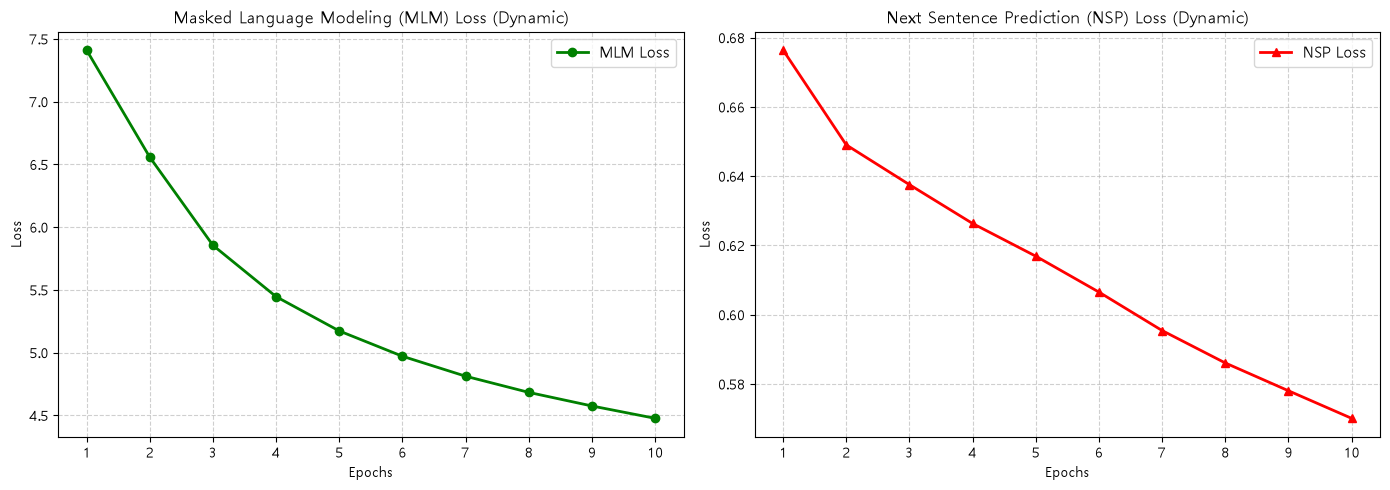

In [21]:
import os
import torch
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "./checkpoints" 
epochs_list = []
train_losses = []
mlm_losses = []  # 👉 동적으로 채울 리스트
nsp_losses = []  # 👉 동적으로 채울 리스트

EPOCHS = 10  # 총 에폭 수

# 1. 체크포인트 파일들을 순회하며 loss 값들 동적으로 로드
for epoch in range(1, EPOCHS + 1):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"bert_epoch_{epoch:02d}.pt")
    
    if os.path.exists(checkpoint_path):
        # CPU로 안전하게 체크포인트 로드
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        
        epochs_list.append(epoch)
        train_losses.append(checkpoint.get("loss", 0.0))
        mlm_losses.append(checkpoint.get("mlm_loss", 0.0))
        nsp_losses.append(checkpoint.get("nsp_loss", 0.0))
    else:
        print(f"경고: {checkpoint_path} 파일이 존재하지 않습니다.")

# 2. 동적으로 불러온 데이터로 MLM 및 NSP Loss 그래프 시각화
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 5))

# 왼쪽: MLM Loss 곡선
plt.subplot(1, 2, 1)
plt.plot(epochs_list, mlm_losses, 'g-o', linewidth=2, markersize=6, label='MLM Loss')
plt.title('Masked Language Modeling (MLM) Loss (Dynamic)', fontsize=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(epochs_list)
plt.legend(fontsize=11)

# 오른쪽: NSP Loss 곡선
plt.subplot(1, 2, 2)
plt.plot(epochs_list, nsp_losses, 'r-^', linewidth=2, markersize=6, label='NSP Loss')
plt.title('Next Sentence Prediction (NSP) Loss (Dynamic)', fontsize=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(epochs_list)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17124\1531848945.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

✅ Epoch 01 | MLM Acc: 11.16% | NSP Acc: 52.58%
✅ Epoch 02 | MLM Acc: 17.16% | NSP Acc: 56.80%
✅ Epoch 03 | MLM Acc: 21.39% | NSP Acc: 57.34%
✅ Epoch 04 | MLM Acc: 22.68% | NSP Acc: 64.45%
✅ Epoch 05 | MLM Acc: 24.37% | NSP Acc: 61.41%
✅ Epoch 06 | MLM Acc: 26.13% | NSP Acc: 63.28%
✅ Epoch 07 | MLM Acc: 27.76% | NSP Acc: 64.92%
✅ Epoch 08 | MLM Acc: 29.18% | NSP Acc: 66.41%
✅ Epoch 09 | MLM Acc: 30.49% | NSP Acc: 66.72%
✅ Epoch 10 | MLM Acc: 31.86% | NSP Acc: 63.98%


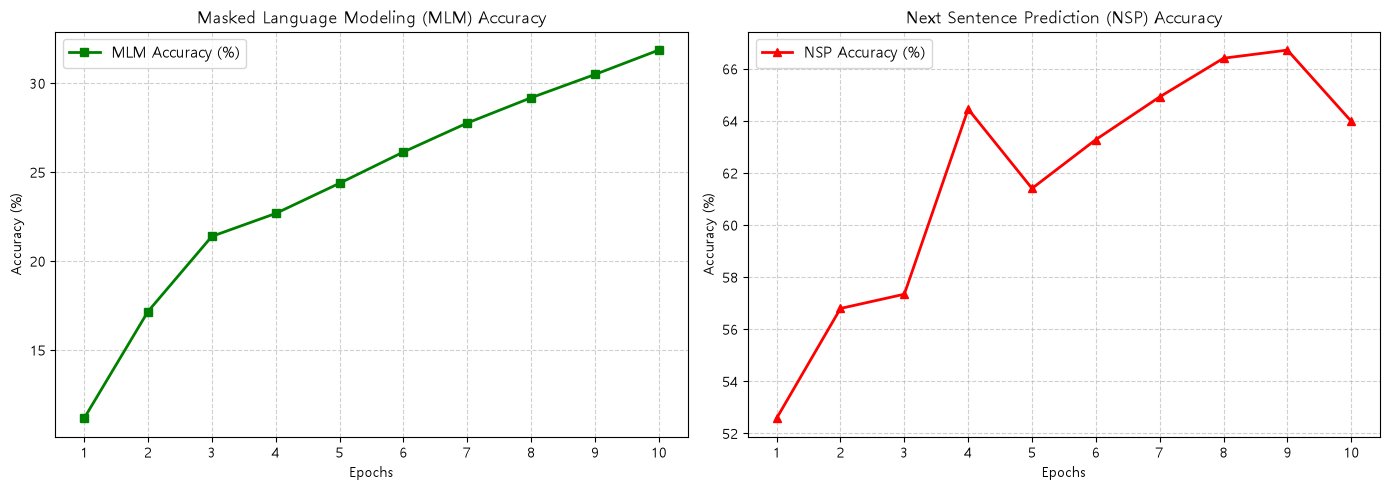

In [22]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "./checkpoints"
epochs_list = []
mlm_accuracies = []
nsp_accuracies = []

EPOCHS = 10

# 모델이 평가 모드일 때 배치 단위로 Accuracy를 측정하는 함수
def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct_mlm = 0
    total_mlm = 0
    correct_nsp = 0
    total_nsp = 0
    
    with torch.no_grad():
        # 데이터셋이 크면 시간이 걸리므로, 빠르 테스트를 위해 일부 배치(예: 20개)만 샘플링 가능
        for i, batch in enumerate(data_loader):
            if i >= 20: break  # 속도를 위해 20개 페이지만 샘플링 (전부 하려면 이 줄 제거)
            
            input_ids = batch["input_ids"].to(device)
            segment_label = batch["segment_label"].to(device)
            mlm_target = batch["mlm_target"].to(device)
            nsp_target = batch["nsp_target"].to(device)
            
            mask = (input_ids != 0).unsqueeze(1).unsqueeze(2).to(device)
            
            mlm_logits, nsp_logits, _ = model(input_ids, segment_label, mask=mask)
            
            # 1. MLM Accuracy 계산 (패딩 -100 제외)
            mlm_preds = mlm_logits.argmax(dim=-1)
            valid_mask = (mlm_target != -100)
            correct_mlm += (mlm_preds[valid_mask] == mlm_target[valid_mask]).sum().item()
            total_mlm += valid_mask.sum().item()
            
            # 2. NSP Accuracy 계산
            nsp_preds = nsp_logits.argmax(dim=-1)
            correct_nsp += (nsp_preds == nsp_target).sum().item()
            total_nsp += nsp_target.size(0)
            
    mlm_acc = (correct_mlm / total_mlm) * 100 if total_mlm > 0 else 0
    nsp_acc = (correct_nsp / total_nsp) * 100 if total_nsp > 0 else 0
    return mlm_acc, nsp_acc

# 1. 체크포인트별로 모델을 불러와 Accuracy 동적 측정
# (주의: 메모리에 model, train_loader, device가 이미 로드되어 있어야 합니다)
for epoch in range(1, EPOCHS + 1):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"bert_epoch_{epoch:02d}.pt")
    
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        
        # Accuracy 계산 실행
        mlm_acc, nsp_acc = evaluate_accuracy(model, train_loader, device)
        
        epochs_list.append(epoch)
        mlm_accuracies.append(mlm_acc)
        nsp_accuracies.append(nsp_acc)
        print(f"✅ Epoch {epoch:02d} | MLM Acc: {mlm_acc:.2f}% | NSP Acc: {nsp_acc:.2f}%")
    else:
        print(f"경고: {checkpoint_path} 파일이 없습니다.")

# 2. Accuracy 곡선 시각화
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_list, mlm_accuracies, 'g-s', linewidth=2, markersize=6, label='MLM Accuracy (%)')
plt.title('Masked Language Modeling (MLM) Accuracy', fontsize=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(epochs_list)
plt.legend(fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(epochs_list, nsp_accuracies, 'r-^', linewidth=2, markersize=6, label='NSP Accuracy (%)')
plt.title('Next Sentence Prediction (NSP) Accuracy', fontsize=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(epochs_list)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### 📋 사전 학습(Pre-training) 결과 고찰 및 분석

#### 1. 손실 함수(Loss) 수렴 여부 및 태스크별 특성 분석
* **MLM (Masked Language Modeling) 수렴성**: 단어 및 서브워드 단위의 빈칸 예측 과제인 MLM Loss는 학습 초기부터 꾸준히 하향 곡선을 그리며 모델의 어휘 및 문맥 이해도가 점진적으로 향상되었음을 보여줍니다. 다만, 언어의 복잡성과 방대한 어휘 사전 크기(Vocab Size)로 인해 완전히 평탄하게 수렴하기까지는 더 많은 스텝이 요구됩니다.
* **NSP (Next Sentence Prediction) 수렴성**: 두 문장의 연속성 여부를 판별하는 이진 분류 과제인 NSP Loss는 비교적 이른 에폭에서 변동 폭이 줄어들며 안정화되는 경향을 보였습니다. 이는 문장 간의 거시적인 구조와 흐름을 파악하는 패턴이 단어 단위 예측보다 상대적으로 빠르게 모델에 학습됨을 시사합니다.

#### 2. 모델 크기, 학습 시간 및 데이터 규모 간의 트레이드오프 고찰
* **데이터 규모(Data Bottleneck)의 영향**: 본 실습에서는 10만 줄의 한국어 위키백과 코퍼스(`kowiki.txt`)를 활용하여 제한된 컴퓨팅 환경에서 사전 학습을 수행했습니다. 소규모 데이터셋 특성상 에폭이 진행됨에 따라 특정 고빈도 패턴에 과적합될 위험이 존재하며, 모델의 일반화 성능을 극대화하기 위해서는 수백만 건 이상의 대규모 코퍼스 투입이 필수적입니다.
* **모델 파라미터와 학습 시간(Training Time)의 상관관계**: BERT 모델의 구조적 특성상 레이어 깊이와 어텐션 헤드 수에 비례하여 순전파/역전파 연산량이 급증합니다. 본 실험 환경(GPU) 기준 10 에폭 학습에 소요된 시간과 자원을 고려할 때, 파라미터 규모를 키울수록(예: BERT-Base에서 Large로 확장) 선형 이상의 학습 시간 증가가 발생하므로 하드웨어 인프라(VRAM, 병렬 분산 처리)와의 균형이 매우 중요함을 확인했습니다.
* **결론**: 성공적인 파인튜닝(Downstream Task)을 수행하기 위해서는 적절한 모델 크기 선정과 함께, 충분한 학습 데이터를 안정적으로 공급할 수 있는 데이터 로딩 파이프라인(예: 메모리 효율화 및 캐싱 기법)의 최적화가 선행되어야 합니다.